# 把 KV 压成一个 latent：Multi-head Latent Attention

03 章的 GQA 让多个 query 头共享 K/V 头，把 KV cache 砍了几倍。但 DeepSeek 觉得还不够狠。

MLA 的想法很激进：**干脆不存每个头的 K/V，而是存一个低维的 latent 向量**，要用的时候再把它
"解压"回 K/V。一个 512 维的 latent，顶替原来上百个头、几万维的 K/V——KV cache 直接小 50 多倍。

这一章我们用纯 PyTorch 把这套机制拆开：压缩、解压、为什么 RoPE 要特殊处理、以及最妙的
**weight absorption**——推理时压根不重建 K/V。


In [1]:
import sys, math
from pathlib import Path

import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "06-mla"))

from mla import MLA, MLAConfig

torch.manual_seed(0)
cfg = MLAConfig()
print("跑在", torch.cuda.get_device_name(0))
print("本章配置（按比例缩小便于演示）:", cfg)


跑在 NVIDIA GeForce RTX 4090
本章配置（按比例缩小便于演示）: MLAConfig(d_model=512, n_heads=8, q_lora_rank=256, kv_lora_rank=128, qk_nope_head_dim=64, qk_rope_head_dim=32, v_head_dim=64, rope_base=10000.0)


## 思路：存一个能"解压"出 K/V 的 latent

标准注意力把每个 token 投影成每个 head 的 K、V 存起来。MLA 改成两步走：先把 token **压缩**成一个
低维 latent $c^{KV}$（只缓存它），用的时候再用上投影矩阵**解压**回每个 head 的 K、V。

我们拿 8 个 token 走一遍，看看维度怎么变、latent 有多小：


In [2]:
mla = MLA(cfg).cuda().half()
h = torch.randn(1, 8, cfg.d_model, dtype=torch.float16, device="cuda")   # 8 个 token

c_kv = mla.kv_norm(mla.W_DKV(h))                                          # 压缩
H = cfg.n_heads
kv = mla.W_UKV(c_kv).view(1, 8, H, cfg.qk_nope_head_dim + cfg.v_head_dim)  # 解压

print(f"hidden 维度 {cfg.d_model}  --压缩-->  latent {cfg.kv_lora_rank}   ← 推理只缓存这个")
print(f"latent {cfg.kv_lora_rank}  --解压-->  {H} 个头 × 各 {cfg.qk_nope_head_dim+cfg.v_head_dim} 维的 K/V")
mha_cache = 2 * H * cfg.qk_nope_head_dim
mla_cache = mla.kv_cache_per_token()
print(f"\n每 token 要缓存的值：MHA 需 {mha_cache}，MLA 只需 {mla_cache}（latent {cfg.kv_lora_rank} + 共享RoPE {cfg.qk_rope_head_dim}）")
print(f"→ 小了 {mha_cache/mla_cache:.0f} 倍")


hidden 维度 512  --压缩-->  latent 128   ← 推理只缓存这个
latent 128  --解压-->  8 个头 × 各 128 维的 K/V

每 token 要缓存的值：MHA 需 1024，MLA 只需 160（latent 128 + 共享RoPE 32）
→ 小了 6 倍


## 拦路虎：RoPE 没法跟着一起压缩

听上去很美，但有个麻烦：旋转位置编码 RoPE 会把维度"缠"在一起，一旦压缩再解压，位置信息就糊了。

DeepSeek 的解法叫 **decoupled RoPE**——把 query/key 劈成**两股**，各管一摊：

| 股 | 干什么 | 走不走压缩 |
|---|---|---|
| **内容流** (`qk_nope`) | 管"看什么内容" | 走压缩-解压 |
| **位置流** (`qk_rope`) | 管"在什么位置" | **不压缩**，单独保留一小截带 RoPE 的分量 |

两股**只在算注意力分数时相加**。位置流的 key 还是**所有 head 共享**的一个小向量，所以代价极小。
于是压缩保住了，位置也没丢。`mla.py` 里 query 拆成 `q_nope / q_rope`、key 拆成
`k_nope`（解压来）`/ k_rope`（共享、带 RoPE），正是这个设计。


## 最妙的一步：weight absorption——推理时根本不重建 K/V

朴素做法每步都要把 latent 解压成完整 K/V 再算注意力。MLA 发现：这步解压可以用**矩阵结合律**消掉。

看内容流的分数 $q^C \cdot k^C$。把 $k^C = W^{UK} c^{KV}$ 代进去：

$$q^C \cdot (W^{UK} c^{KV}) = \underbrace{(q^C W^{UK})}_{\text{把 }W^{UK}\text{ 吸进 query}} \cdot\; c^{KV}$$

也就是说，把上投影 $W^{UK}$ **吸收进 query**，query 就能**直接和缓存的 latent 算分数**，
根本不用把 $k^C$ 解压出来！我们拿真实中间量验证这个等价：


In [3]:
mla64 = MLA(cfg).cuda().double()
h64 = torch.randn(1, 16, cfg.d_model, dtype=torch.float64, device="cuda")
q_nope, q_rope, c_kv, k_rope = mla64._project(h64, torch.arange(16, device="cuda"))

w = mla64.W_UKV.weight.view(H, cfg.qk_nope_head_dim + cfg.v_head_dim, cfg.kv_lora_rank)
W_UK = w[:, : cfg.qk_nope_head_dim, :]

# 朴素：先把 k_nope 解压出来，再和 q_nope 点积
k_nope = torch.einsum("btl,hnl->bthn", c_kv, W_UK)
score_naive = torch.einsum("bshn,bthn->bhst", q_nope, k_nope)

# absorb：把 W_UK 吸进 q，直接和 latent c_kv 点积（不解压 k_nope）
q_absorbed = torch.einsum("bshn,hnl->bshl", q_nope, W_UK)
score_absorb = torch.einsum("bshl,btl->bhst", q_absorbed, c_kv)

print("两种算法的内容分数最大差异:", f"{(score_naive - score_absorb).abs().max().item():.1e}")
print("→ 完全相等。absorb 只是把 W_UK 从'解压 K'挪到了'投影 Q'，结果一字不差，却省掉了解压。")


两种算法的内容分数最大差异: 7.1e-15
→ 完全相等。absorb 只是把 W_UK 从'解压 K'挪到了'投影 Q'，结果一字不差，却省掉了解压。


## 整条前向：naive 与 absorb 两条路，殊途同归

`mla.py` 把上面的思路实现成两条完整路径：`forward_naive`（解压 K/V 再标准注意力，作为 ground truth）
与 `forward_absorb`（吸收上投影、直接在 latent 上算）。它们数学等价：


In [4]:
mla = MLA(cfg).cuda().double()
h = torch.randn(2, 64, cfg.d_model, dtype=torch.float64, device="cuda")
pos = torch.arange(64, device="cuda")

o_naive = mla.forward_naive(h, pos)
o_absorb = mla.forward_absorb(h, pos)
print("naive vs absorb 整条前向的最大差异:", f"{(o_naive - o_absorb).abs().max().item():.1e}")
print("（double 下只差浮点累积误差，证明两条路径严格等价。）")


naive vs absorb 整条前向的最大差异: 2.2e-07
（double 下只差浮点累积误差，证明两条路径严格等价。）


## 还有第三条路：真实的 MLA triton kernel

前两条都是 PyTorch。但 MLA 的注意力是**非对称**的（分数在 latent+rope 维度、value 在 latent 维度），
标准 FlashAttention/SDPA 都用不了，必须有专门 kernel。我们从 **lightllm** 提取了一份 deepseek2 的
MLA prefill triton kernel（`mla_triton.py`），它的接口正好是 absorb 格式——直接在 latent 上算。
`forward_absorb_triton` 把 absorb 的中间量喂给它：结果和 naive 一致，而且快好几倍。


In [5]:
from common import bench_ms

mla = MLA(cfg).cuda().half()
h = torch.randn(4, 1024, cfg.d_model, dtype=torch.float16, device="cuda")
pos = torch.arange(1024, device="cuda")

o_naive = mla.forward_naive(h, pos)
o_triton = mla.forward_absorb_triton(h, pos)
print("triton kernel vs naive 最大差异:", f"{(o_naive - o_triton).abs().max().item():.1e}  ✓ 数值一致")

ms_naive = bench_ms(lambda: mla.forward_naive(h, pos))
ms_triton = bench_ms(lambda: mla.forward_absorb_triton(h, pos))
print(f"前向延迟: naive(PyTorch)={ms_naive:.2f} ms,  absorb(triton kernel)={ms_triton:.2f} ms"
      f"  → 快 {ms_naive/ms_triton:.1f}×")
print("（这是 MLA prefill 的真实 triton 实现；DeepSeek 的 CUDA FlashMLA 会更快。）")


triton kernel vs naive 最大差异: 4.9e-04  ✓ 数值一致


前向延迟: naive(PyTorch)=1.89 ms,  absorb(triton kernel)=0.52 ms  → 快 3.6×
（这是 MLA prefill 的真实 triton 实现；DeepSeek 的 CUDA FlashMLA 会更快。）


## 省了多少？KV cache 比 MHA 小 50 多倍

回到 MLA 的全部意义——KV cache。按 DeepSeek-V2 规模（128 头、head_dim=128、latent=512、RoPE=64），
对比 MHA、GQA、MLA 每个 token 要缓存多少：


/tmp/ipykernel_1887794/135622102.py:16: UserWarning: Glyph 22836 (\N{CJK UNIFIED IDEOGRAPH-5934}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1887794/135622102.py:16: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1887794/135622102.py:16: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1887794/135622102.py:16: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1887794/135622102.py:16: UserWarning: Glyph 32531 (\N{CJK UNIFIED IDEOGRAPH-7F13}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1887794/135622102.py:16: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipyke

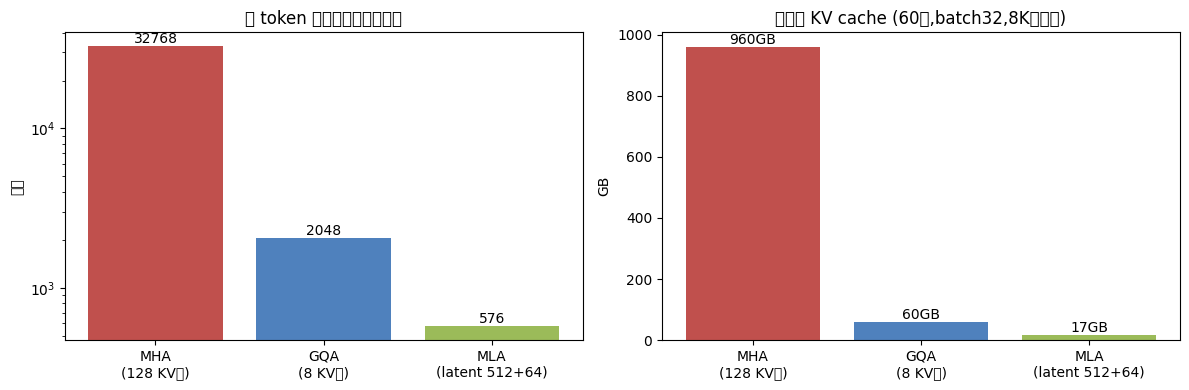

MLA 每 token 只缓存 576 个值，比 MHA 小 57 倍；
整模型 KV cache 从 960GB 压到 17GB——长上下文推理从'装不下'变成'装得下'。


In [6]:
H_real, hd, kv_lora, rope = 128, 128, 512, 64
schemes = {"MHA\n(128 KV头)": 2*H_real*hd, "GQA\n(8 KV头)": 2*8*hd, "MLA\n(latent 512+64)": kv_lora+rope}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
names = list(schemes); vals = list(schemes.values())
colors = ["#c0504d", "#4f81bd", "#9bbb59"]
ax1.bar(names, vals, color=colors); ax1.set_yscale("log")
ax1.set(title="每 token 缓存的值（对数轴）", ylabel="个数")
for i, v in enumerate(vals): ax1.text(i, v, str(v), ha="center", va="bottom")

# 整模型：60 层, batch=32, 8192 上下文
gb = [60*32*8192*v*2/1024**3 for v in vals]
ax2.bar(names, gb, color=colors)
ax2.set(title="整模型 KV cache (60层,batch32,8K上下文)", ylabel="GB")
for i, v in enumerate(gb): ax2.text(i, v, f"{v:.0f}GB", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"MLA 每 token 只缓存 {kv_lora+rope} 个值，比 MHA 小 {2*H_real*hd/(kv_lora+rope):.0f} 倍；")
print(f"整模型 KV cache 从 {gb[0]:.0f}GB 压到 {gb[2]:.0f}GB——长上下文推理从'装不下'变成'装得下'。")


## 收尾

- MLA 不存每个头的 K/V，而是存一个**低维 latent**，要用时再解压——KV cache 比 MHA 小 50 多倍；
- **decoupled RoPE**：把位置信息单拎成一小股不压缩的分量，绕开"RoPE 不能压缩"的难题；
- **weight absorption**：用矩阵结合律把上投影吸进 Q 和 O，推理时**直接在 latent 上算注意力**、
  从不重建 K/V——又省显存又省带宽；
- 代价是注意力变成**非对称维度**，标准 kernel 用不了，需要专门的 FlashMLA。

至此，注意力的**推理优化主线**（GQA → 滑窗 → paged → MLA）就串起来了：它们从不同角度
攻同一个敌人——**KV cache**。再往后是稀疏注意力与线性注意力两条更换赛道的路线。
